<a href="https://colab.research.google.com/github/Mradul2k04/Machine_Learning/blob/Project/01_Approval_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
#import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
#Read the dataset of hdfc_loan
df=pd.read_csv("/content/hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv")

In [63]:
df

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,...,10.965,Neutral,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,...,3.268,Negative,Hindu,Kerala,Trivandrum,217843,7.040000e+11,9176504718,krishna.mehta@example.in,Customer Support Executive
997,HDFC100998,HDFC Bank,Rohan Verma,Female,No,1,Graduate,Salaried,24392,11337,...,0.703,Positive,Hindu,Delhi,New Delhi,89211,9.954289e+10,9966866798,rohan.verma@example.in,Driver
998,HDFC100999,HDFC Bank,Ananya Joshi,Female,No,2,Graduate,Salaried,64803,94136,...,0.377,Negative,Hindu,Gujarat,Ahmedabad,532976,6.170000e+11,9103847156,ananya.joshi@example.in,Electrician


In [64]:
#Selecting the columns in which we have to perform the operation
df_columns=df[["Applicant_Income","Annual_Household_Income","CIBIL_Score","Loan_Status","Debt_to_Income_Ratio"]].copy()
df_columns.reset_index()

,index,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio
0,0,56976,683712,699,Approved,0.098
1,1,1856,22272,707,Rejected,4.939
2,2,64553,774636,641,Approved,0.000
3,3,88450,1061400,677,Approved,0.301
4,4,9539,114468,594,Approved,0.000
...,...,...,...,...,...,...
995,995,44713,536556,707,Approved,0.116
996,996,70886,850632,561,Rejected,0.284
997,997,24392,428748,725,Approved,0.966
998,998,64803,1907268,679,Approved,0.214


In [65]:
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio
0,56976,683712,699,Approved,0.098
1,1856,22272,707,Rejected,4.939
2,64553,774636,641,Approved,0.000
3,88450,1061400,677,Approved,0.301
4,9539,114468,594,Approved,0.000
...,...,...,...,...,...
995,44713,536556,707,Approved,0.116
996,70886,850632,561,Rejected,0.284
997,24392,428748,725,Approved,0.966
998,64803,1907268,679,Approved,0.214


In [66]:
df_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_Income         1000 non-null   int64  
 1   Annual_Household_Income  1000 non-null   int64  
 2   CIBIL_Score              1000 non-null   int64  
 3   Loan_Status              1000 non-null   object 
 4   Debt_to_Income_Ratio     1000 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 39.2+ KB


In [67]:
#Converting the loan status into 1 or 0 form to get the integer value
df_columns['Loan_Status'] = np.where(df_columns['Loan_Status'] == "Approved", 1, 0)

In [68]:
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio
0,56976,683712,699,1,0.098
1,1856,22272,707,0,4.939
2,64553,774636,641,1,0.000
3,88450,1061400,677,1,0.301
4,9539,114468,594,1,0.000
...,...,...,...,...,...
995,44713,536556,707,1,0.116
996,70886,850632,561,0,0.284
997,24392,428748,725,1,0.966
998,64803,1907268,679,1,0.214


In [69]:
df_columns.describe()

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio
count,1000.000000,1.000000e+03,1000.00000,1000.000000,1000.000000
mean,42430.057000,6.258861e+05,653.01300,0.653000,148.118157
std,28133.210769,4.724545e+05,73.83654,0.476254,1974.599103
min,0.000000,0.000000e+00,384.00000,0.000000,0.000000
25%,18260.000000,2.639520e+05,605.75000,0.000000,0.031000
50%,40675.500000,5.512440e+05,654.00000,1.000000,0.332000
75%,61037.250000,8.565480e+05,704.00000,1.000000,0.795000
max,149266.000000,2.555340e+06,878.00000,1.000000,38342.000000


In [70]:
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio
0,56976,683712,699,1,0.098
1,1856,22272,707,0,4.939
2,64553,774636,641,1,0.000
3,88450,1061400,677,1,0.301
4,9539,114468,594,1,0.000
...,...,...,...,...,...
995,44713,536556,707,1,0.116
996,70886,850632,561,0,0.284
997,24392,428748,725,1,0.966
998,64803,1907268,679,1,0.214


In [71]:
#Calculating the mean of the loan status to get the overall approval rate in percentage
overall_approval_rate=df_columns['Loan_Status'].mean()*100
overall_approval_rate

np.float64(65.3)

In [72]:
df_columns["Annual_Debt"]=df["Annual_Household_Income"]*df["Debt_to_Income_Ratio"]
df_columns["Financial_Indicator"]=np.where(df_columns["Loan_Status"]==0,"Not Applicable",np.where(df_columns["Annual_Debt"]>df_columns["Annual_Household_Income"],"Critical",np.where(df_columns["Annual_Debt"]<df_columns["Annual_Household_Income"],"Healthly","Manageable")))
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio,Annual_Debt,Financial_Indicator
0,56976,683712,699,1,0.098,67003.776,Healthly
1,1856,22272,707,0,4.939,110001.408,Not Applicable
2,64553,774636,641,1,0.000,0.000,Healthly
3,88450,1061400,677,1,0.301,319481.400,Healthly
4,9539,114468,594,1,0.000,0.000,Healthly
...,...,...,...,...,...,...,...
995,44713,536556,707,1,0.116,62240.496,Healthly
996,70886,850632,561,0,0.284,241579.488,Not Applicable
997,24392,428748,725,1,0.966,414170.568,Healthly
998,64803,1907268,679,1,0.214,408155.352,Healthly


In [73]:
#Calculating the Approval rate per person
df_columns["Approval_Rate_Per_Person(%)"]=np.where(df_columns["Annual_Debt"]>df["Annual_Household_Income"],25,np.where(df_columns["Annual_Debt"]<df["Annual_Household_Income"],75,50))
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio,Annual_Debt,Financial_Indicator,Approval_Rate_Per_Person(%)
0,56976,683712,699,1,0.098,67003.776,Healthly,75
1,1856,22272,707,0,4.939,110001.408,Not Applicable,25
2,64553,774636,641,1,0.000,0.000,Healthly,75
3,88450,1061400,677,1,0.301,319481.400,Healthly,75
4,9539,114468,594,1,0.000,0.000,Healthly,75
...,...,...,...,...,...,...,...,...
995,44713,536556,707,1,0.116,62240.496,Healthly,75
996,70886,850632,561,0,0.284,241579.488,Not Applicable,75
997,24392,428748,725,1,0.966,414170.568,Healthly,75
998,64803,1907268,679,1,0.214,408155.352,Healthly,75


In [74]:
#To determine the rate at which approvals change.
df_columns["dA"]=df_columns["Approval_Rate_Per_Person(%)"].diff()
df_columns["dX"]=df_columns["Annual_Debt"].diff()
df_columns['dA_dX']=df_columns["dA"]/df_columns["dX"]
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio,Annual_Debt,Financial_Indicator,Approval_Rate_Per_Person(%),dA,dX,dA_dX
0,56976,683712,699,1,0.098,67003.776,Healthly,75,NaN,NaN,NaN
1,1856,22272,707,0,4.939,110001.408,Not Applicable,25,-50.0,42997.632,-0.001163
2,64553,774636,641,1,0.000,0.000,Healthly,75,50.0,-110001.408,-0.000455
3,88450,1061400,677,1,0.301,319481.400,Healthly,75,0.0,319481.400,0.000000
4,9539,114468,594,1,0.000,0.000,Healthly,75,0.0,-319481.400,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...
995,44713,536556,707,1,0.116,62240.496,Healthly,75,0.0,35091.816,0.000000
996,70886,850632,561,0,0.284,241579.488,Not Applicable,75,0.0,179338.992,0.000000
997,24392,428748,725,1,0.966,414170.568,Healthly,75,0.0,172591.080,0.000000
998,64803,1907268,679,1,0.214,408155.352,Healthly,75,0.0,-6015.216,-0.000000


## #Task 1
Perform exploratory analysis.

Study:

Income distribution

Credit score distribution

Approval distribution



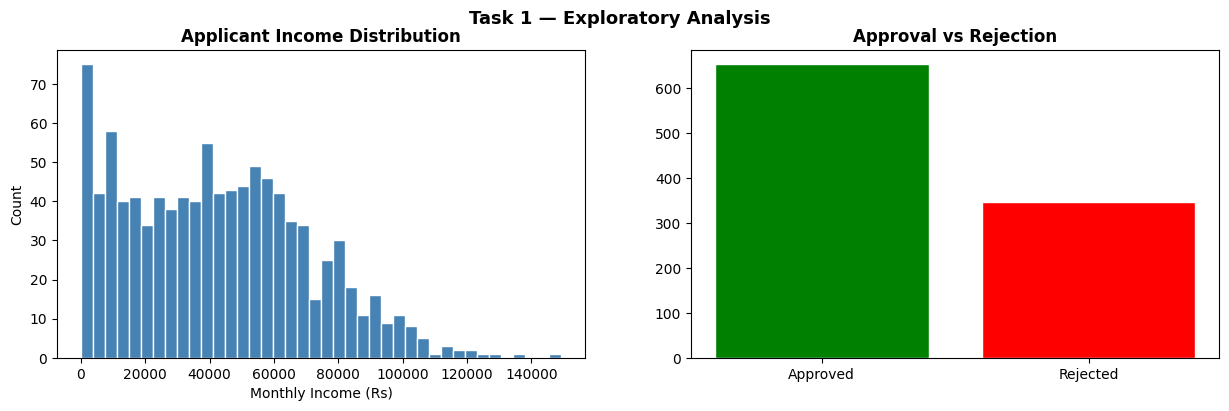

In [75]:
fig,axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df_columns['Applicant_Income'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Applicant Income Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Income (Rs)')
axes[0].set_ylabel('Count')

financial_indicator_count = df_columns['Loan_Status'].value_counts()
labels = ["Approved","Rejected"]
axes[1].bar(labels, financial_indicator_count.values,
            color=['green', 'red'], edgecolor='white')
axes[1].set_title('Approval vs Rejection', fontweight='bold')

plt.suptitle('Task 1 — Exploratory Analysis', fontsize=13, fontweight='bold')
plt.show()

#Task 2
Group applicants into bands.

Example:

Income Bands

Low Income

Middle Income

High Income

Premium Income



In [76]:
df_columns["Applicant_Income"]

,Applicant_Income
0,56976
1,1856
2,64553
3,88450
4,9539
...,...
995,44713
996,70886
997,24392
998,64803


In [77]:
#Income Bands
income_bins=[0,20000,50000,90000,np.inf]
income_lables=["Low Income","Middle Income","High Income","Premium Income"]
df_columns["Income Band"]=pd.cut(df_columns["Applicant_Income"],bins=income_bins,labels=income_lables)
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio,Annual_Debt,Financial_Indicator,Approval_Rate_Per_Person(%),dA,dX,dA_dX,Income Band
0,56976,683712,699,1,0.098,67003.776,Healthly,75,NaN,NaN,NaN,High Income
1,1856,22272,707,0,4.939,110001.408,Not Applicable,25,-50.0,42997.632,-0.001163,Low Income
2,64553,774636,641,1,0.000,0.000,Healthly,75,50.0,-110001.408,-0.000455,High Income
3,88450,1061400,677,1,0.301,319481.400,Healthly,75,0.0,319481.400,0.000000,High Income
4,9539,114468,594,1,0.000,0.000,Healthly,75,0.0,-319481.400,-0.000000,Low Income
...,...,...,...,...,...,...,...,...,...,...,...,...
995,44713,536556,707,1,0.116,62240.496,Healthly,75,0.0,35091.816,0.000000,Middle Income
996,70886,850632,561,0,0.284,241579.488,Not Applicable,75,0.0,179338.992,0.000000,High Income
997,24392,428748,725,1,0.966,414170.568,Healthly,75,0.0,172591.080,0.000000,Middle Income
998,64803,1907268,679,1,0.214,408155.352,Healthly,75,0.0,-6015.216,-0.000000,High Income


In [78]:
# CIBIL Score Bands
cibil_bins   = [0, 550, 650, 750, np.inf]
cibil_labels = ['Poor', 'Fair', 'Good', 'Excellent']
df_columns['CIBIL_Band'] = pd.cut(df_columns['CIBIL_Score'], bins=cibil_bins, labels=cibil_labels)

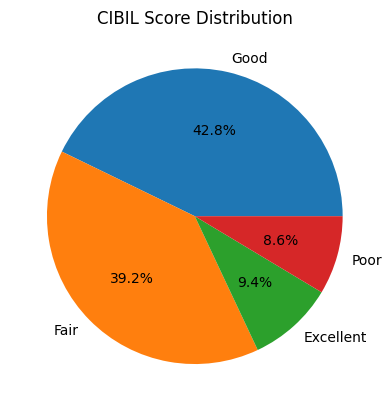

In [79]:
plt.pie(df_columns['CIBIL_Band'].value_counts(), labels=df_columns['CIBIL_Band'].value_counts().index, autopct='%1.1f%%')
plt.title('CIBIL Score Distribution')
plt.show()

In [80]:
# Debt-to-Income Ratio Bands
dti_bins   = [-1,0, 0.2, 0.4, 0.6, np.inf]
dti_labels = ['Zero DTI','Low DTI', 'Moderate DTI', 'High DTI', 'Very High DTI']
df_columns['DTI_Band'] = pd.cut(df_columns['Debt_to_Income_Ratio'], bins=dti_bins, labels=dti_labels)
df_columns

,Applicant_Income,Annual_Household_Income,CIBIL_Score,Loan_Status,Debt_to_Income_Ratio,Annual_Debt,Financial_Indicator,Approval_Rate_Per_Person(%),dA,dX,dA_dX,Income Band,CIBIL_Band,DTI_Band
0,56976,683712,699,1,0.098,67003.776,Healthly,75,NaN,NaN,NaN,High Income,Good,Low DTI
1,1856,22272,707,0,4.939,110001.408,Not Applicable,25,-50.0,42997.632,-0.001163,Low Income,Good,Very High DTI
2,64553,774636,641,1,0.000,0.000,Healthly,75,50.0,-110001.408,-0.000455,High Income,Fair,Zero DTI
3,88450,1061400,677,1,0.301,319481.400,Healthly,75,0.0,319481.400,0.000000,High Income,Good,Moderate DTI
4,9539,114468,594,1,0.000,0.000,Healthly,75,0.0,-319481.400,-0.000000,Low Income,Fair,Zero DTI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,44713,536556,707,1,0.116,62240.496,Healthly,75,0.0,35091.816,0.000000,Middle Income,Good,Low DTI
996,70886,850632,561,0,0.284,241579.488,Not Applicable,75,0.0,179338.992,0.000000,High Income,Fair,Moderate DTI
997,24392,428748,725,1,0.966,414170.568,Healthly,75,0.0,172591.080,0.000000,Middle Income,Good,Very High DTI
998,64803,1907268,679,1,0.214,408155.352,Healthly,75,0.0,-6015.216,-0.000000,High Income,Good,Moderate DTI


#Task 3
Calculate approval rate for each band.


In [81]:
#Approval Rate for Income
approval_rate_income=df_columns.groupby("Income Band",observed=True)["Approval_Rate_Per_Person(%)"].mean()
approval_rate_income

,Approval_Rate_Per_Person(%)
Income Band,
Low Income,45.703125
Middle Income,69.134897
High Income,74.406528
Premium Income,75.000000


In [82]:
#Approval Rate for CIBL Score
approval_rate_cibil=df_columns.groupby("CIBIL_Band",observed=True)["Approval_Rate_Per_Person(%)"].mean()
approval_rate_cibil

,Approval_Rate_Per_Person(%)
CIBIL_Band,
Poor,60.465116
Fair,65.943878
Good,65.186916
Excellent,64.627660


In [83]:
#Approval Rate for DIT
approval_rate_dti=df_columns.groupby("DTI_Band",observed=True)["Approval_Rate_Per_Person(%)"].mean()
approval_rate_dti

,Approval_Rate_Per_Person(%)
DTI_Band,
Zero DTI,74.671053
Low DTI,75.000000
Moderate DTI,75.000000
High DTI,75.000000
Very High DTI,44.908815


# Task 4
Use numerical differentiation to calculate the rate of change in approval rates.

Example:

np.gradient(approval_rates)


In [84]:
# calculate the rate of change in approval rates in income
income_grad=np.gradient(approval_rate_income)
income_grad

array([23.43177236, 14.35170159,  2.93255132,  0.59347181])

In [85]:
income_grad_dict = dict(zip(approval_rate_income.index,income_grad.data))
income_grad_dict

{'Low Income': 23.431772360703818,
 'Middle Income': 14.351701594955493,
 'High Income': 2.9325513196480912,
 'Premium Income': 0.5934718100890137}

In [86]:
cred_grad = np.gradient(approval_rate_cibil)
cred_grad

array([ 5.47876127,  2.3608998 , -0.65810899, -0.55925631])

In [87]:
cred_grad_dict = dict(zip(approval_rate_cibil.index,cred_grad.data))
cred_grad_dict

{'Poor': 5.4787612719506384,
 'Fair': 2.360899804390346,
 'Good': -0.6581089882761617,
 'Excellent': -0.5592563133823774}

In [88]:
dti_grad = np.gradient(approval_rate_dti)
dti_grad

array([  0.32894737,   0.16447368,   0.        , -15.04559271,
       -30.09118541])

In [89]:
dti_grad_dict = dict(zip(approval_rate_dti.index,dti_grad.data))
dti_grad_dict

{'Zero DTI': 0.3289473684210549,
 'Low DTI': 0.16447368421052744,
 'Moderate DTI': 0.0,
 'High DTI': -15.045592705167174,
 'Very High DTI': -30.091185410334347}

# Task 5

Identify critical thresholds where approval rates increase or decrease sharply.


In [90]:
#Thereshold for approval rates
min_income_grad = income_grad.min()
max_income_grad = income_grad.max()
min_cred_grad = cred_grad.min()
max_cred_grad = cred_grad.max()
min_dti_grad = dti_grad.min()
max_dti_grad = dti_grad.max()
print("Minimum Approval Rate in Income Band: ",min_income_grad)
print("Maximum Approval Rate in Income Band: ",max_income_grad)
print("Minimum Approval Rate in CIBIL Band: ",min_cred_grad)
print("Maximum Approval Rate in CIBIL Band: ",max_cred_grad)
print("Minimum Approval Rate in DTI Band: ",min_dti_grad)
print("Maximum Approval Rate in DTI Band: ",max_dti_grad)

Minimum Approval Rate in Income Band:  0.5934718100890137
Maximum Approval Rate in Income Band:  23.431772360703818
Minimum Approval Rate in CIBIL Band:  -0.6581089882761617
Maximum Approval Rate in CIBIL Band:  5.4787612719506384
Minimum Approval Rate in DTI Band:  -30.091185410334347
Maximum Approval Rate in DTI Band:  0.3289473684210549


## Visualizations

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

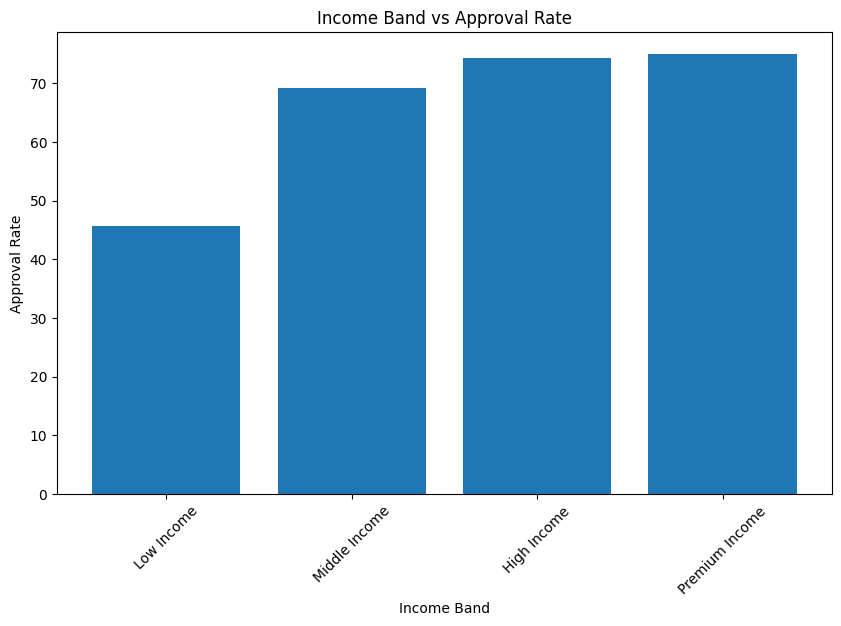

In [91]:
#Visual 1
#Income Band vs Approval Rate

plt.figure(figsize=(10, 6))
plt.bar(approval_rate_income.index, approval_rate_income.values)
plt.xlabel('Income Band')
plt.ylabel('Approval Rate')
plt.title('Income Band vs Approval Rate')
plt.xticks(rotation=45)
plt

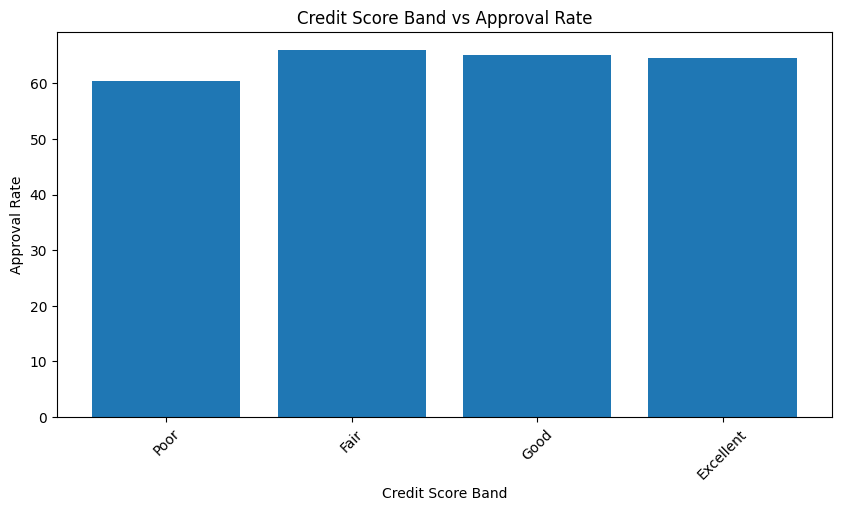

In [92]:
#Visual 2
#Credit Score Band vs Approval Rate

plt.figure(figsize=(10, 5))
plt.bar(approval_rate_cibil.index, approval_rate_cibil.values)
plt.xlabel('Credit Score Band')
plt.ylabel('Approval Rate')
plt.title('Credit Score Band vs Approval Rate')
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Rate of Change Curve')

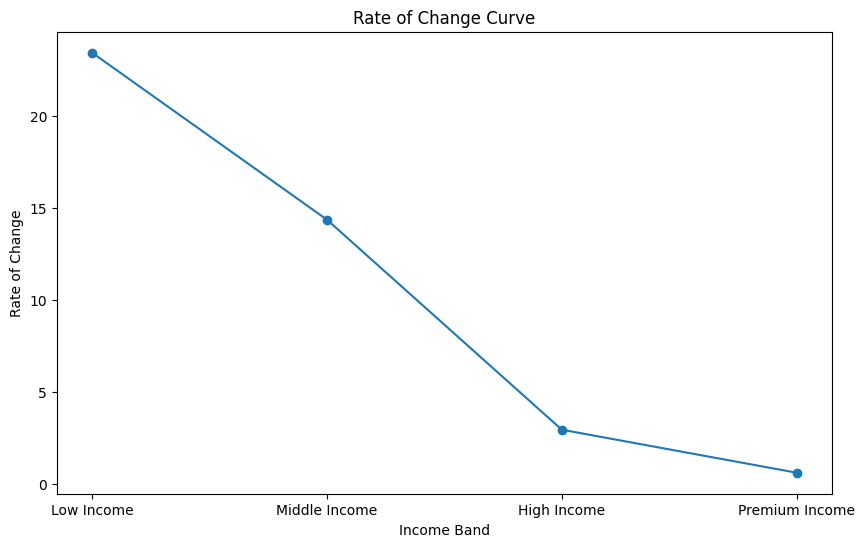

In [93]:
#Visual 3
#Rate of Change Curve

plt.figure(figsize=(10, 6))
plt.plot(approval_rate_income.index, income_grad, marker='o')
plt.xlabel('Income Band')
plt.ylabel('Rate of Change')#
plt.title('Rate of Change Curve')

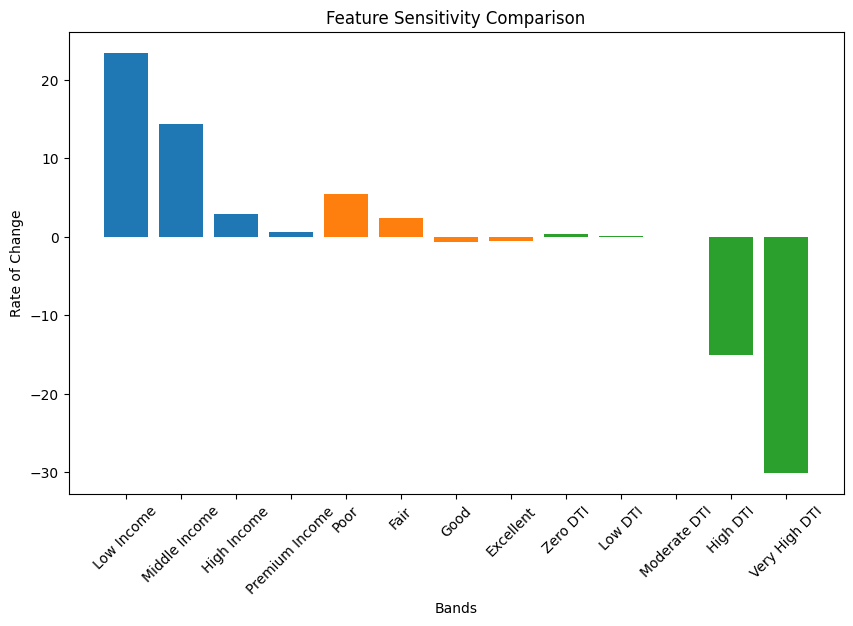

In [94]:
#Visual 4
#Feature Sensitivity Comparison
plt.figure(figsize=(10, 6))
plt.bar(approval_rate_income.index, income_grad, label='Income Band')
plt.bar(approval_rate_cibil.index, cred_grad, label='Credit Score Band')
plt.bar(approval_rate_dti.index, dti_grad, label='DTI Band')
plt.xlabel('Bands')
plt.ylabel('Rate of Change')
plt.xticks(rotation=45)
plt.title('Feature Sensitivity Comparison')
plt.show()
